# 09 - Selección del método ganador y extensión del mismo a los horizontes entre 1 y 24 horas

Este notebook realiza dos tareas:

1. Seleccionar el método definitivo a partir del conjunto de validación de 2024.
2. Extender el análisis del método seleccionado a todos los horizontes comprendidos entre 1 y 24 horas.

La selección se realiza sin utilizar el conjunto de prueba de 2025, que queda reservado para la evaluación final del método seleccionado.

## Criterio metodológico

La selección se organiza en los siguientes dos niveles; en primer lugar, se considera la admisibilidad explicativa obtenida mediante el notebook 08_explainability_audit.

En segundo lugar, los modelos admisibles se ordenan mediante una puntuación cuantitativa obtenida a partir del conjunto de validación (2024). Para cada horizonte de selección $h \in \{1,4,12,24\}$, se combinan estos tres bloques:

- Precisión puntual: MAE y RMSE normalizados
- Calidad de los intervalos: $\textit{interval score}$ normalizado
- Calibración: pérdida de cobertura por debajo de la nominal del 80 %

La anchura media no se introduce como término independiente porque está incorporada en el $\textit{interval score}$.

In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path
from typing import Any, Iterable, Sequence

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from catboost import CatBoostRegressor, Pool
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere un modelo entrenado CatBoost para extender el modelo ganador a 1-24 horas."
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
DATA_EXTENSION_DIR = DATA_MODELING_DIR / "horizon_extension_01_24"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_EXTENSION_DIR = MODELS_DIR / "catboost_cqr_horizon_extension"

for directory in [DATA_EXTENSION_DIR, REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_PREDICTIONS_DIR, REPORTS_INTERVALS_DIR, MODELS_EXTENSION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SELECTION_HORIZONS: list[int] = [1, 4, 12, 24]
EXTENSION_HORIZONS: list[int] = list(range(1, 25))

TRAIN_SPLIT = "train"
CALIBRATION_SPLIT = "calibration"
VALIDATION_SPLIT = "validation"
TEST_SPLIT = "test"

ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA
LOWER_QUANTILE = ALPHA / 2
UPPER_QUANTILE = 1 - ALPHA / 2
MEDIAN_QUANTILE = 0.50

RANDOM_STATE = 42
MIN_ACCEPTABLE_COVERAGE = 0.75  # control de infracobertura severa, no umbral rígido de 0.80.

# Pesos de la puntuación de selección.
SELECTION_WEIGHT_POINT = 0.40
SELECTION_WEIGHT_INTERVAL = 0.40
SELECTION_WEIGHT_COVERAGE = 0.20

RUN_HORIZON_EXTENSION = True
REUSE_EXISTING_EXTENSION_TABLES = False
SAVE_EXTENSION_MODELS = True

MODEL_REGISTRY: dict[str, dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "interval_prefix": "split_conformal_baseline",
        "label": "Modelo base + SC",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Lineal",
        "interval_prefix": "cqr_linear_regression",
        "label": "Regresión lineal + CQR",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LGBM",
        "interval_prefix": "cqr_lightgbm",
        "label": "LightGBM + CQR",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CAT",
        "interval_prefix": "cqr_catboost",
        "label": "CatBoost + CQR",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
MODEL_ORDER_MAP = {model_id: i for i, model_id in enumerate(MODEL_ORDER)}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Intervalos previos: {REPORTS_INTERVALS_DIR}")
print(f"Datasets extensión: {DATA_EXTENSION_DIR}")
print(f"Modelos extensión: {MODELS_EXTENSION_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")
print(
    "Pesos selección: "
    f"puntual={SELECTION_WEIGHT_POINT:.2f}, "
    f"interval score={SELECTION_WEIGHT_INTERVAL:.2f}, "
    f"infracobertura={SELECTION_WEIGHT_COVERAGE:.2f}"
)

Raíz del proyecto: c:\trabajo_github
Intervalos previos: c:\trabajo_github\reports\intervals
Datasets extensión: c:\trabajo_github\data\modeling\horizon_extension_01_24
Modelos extensión: c:\trabajo_github\models\catboost_cqr_horizon_extension
Cobertura nominal: 80%
Pesos selección: puntual=0.40, interval score=0.40, infracobertura=0.20


## Funciones auxiliares

A continuación, se definen funciones para efectuar el guardado de las tablas y las figuras, calcular las métricas, normalizar los valores por horizonte y cargar los intervalos generados por los notebooks anteriores.

In [3]:
SAVED_FIGURE_PATHS: list[Path] = []
SAVED_TABLE_PATHS: list[Path] = []

def save_dataframe_csv(df: pd.DataFrame, path: Path, **kwargs: Any) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, **kwargs)
    SAVED_TABLE_PATHS.append(path)
    print(f"Tabla guardada: {path}")
    return path

def save_figure(fig: plt.Figure, path: Path, **kwargs: Any) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    save_kwargs = {"dpi": 300, "bbox_inches": "tight"}
    save_kwargs.update(kwargs)
    fig.savefig(path, **save_kwargs)
    SAVED_FIGURE_PATHS.append(path)
    print(f"Figura guardada: {path}")
    return path

def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float = ALPHA,
) -> np.ndarray:
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty

def finite_sample_quantile(scores: pd.Series | np.ndarray, alpha: float = ALPHA) -> tuple[float, float]:
    clean_scores = np.asarray(scores, dtype=float)
    clean_scores = clean_scores[~np.isnan(clean_scores)]
    if len(clean_scores) == 0:
        raise ValueError("No hay puntuaciones de no conformidad válidas para calcular el q_hat.")

    n_scores = len(clean_scores)
    quantile_level = np.ceil((n_scores + 1) * (1 - alpha)) / n_scores
    quantile_level = min(float(quantile_level), 1.0)

    try:
        q_hat = float(np.quantile(clean_scores, quantile_level, method="higher"))
    except TypeError:
        q_hat = float(np.quantile(clean_scores, quantile_level, interpolation="higher"))

    return q_hat, quantile_level

def compute_metrics_from_intervals(df: pd.DataFrame) -> dict[str, Any]:
    valid = df.dropna(subset=["y_true", "y_pred_central", "lower", "upper"]).copy()
    if valid.empty:
        raise ValueError("No hay registros válidos para calcular las métricas.")

    covered = (valid["y_true"] >= valid["lower"]) & (valid["y_true"] <= valid["upper"])
    widths = valid["upper"] - valid["lower"]
    scores = interval_score(valid["y_true"], valid["lower"], valid["upper"], ALPHA)

    mae = mean_absolute_error(valid["y_true"], valid["y_pred_central"])
    rmse = float(np.sqrt(mean_squared_error(valid["y_true"], valid["y_pred_central"])))

    empirical_coverage = float(covered.mean())
    undercoverage_loss = max(0.0, NOMINAL_COVERAGE - empirical_coverage)
    overcoverage_margin = max(0.0, empirical_coverage - NOMINAL_COVERAGE)

    return {
        "n_samples": int(len(valid)),
        "mae": float(mae),
        "rmse": float(rmse),
        "empirical_coverage": empirical_coverage,
        "coverage_error": float(empirical_coverage - NOMINAL_COVERAGE),
        "undercoverage_loss": float(undercoverage_loss),
        "overcoverage_margin": float(overcoverage_margin),
        "mean_width": float(widths.mean()),
        "median_width": float(widths.median()),
        "mean_interval_score": float(scores.mean()),
        "median_interval_score": float(np.median(scores)),
        "miss_lower_pct": float((valid["y_true"] < valid["lower"]).mean() * 100),
        "miss_upper_pct": float((valid["y_true"] > valid["upper"]).mean() * 100),
    }

def first_existing_column(df: pd.DataFrame, candidates: Sequence[str], purpose: str) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        f"No se encontró ninguna columna para {purpose}. "
        f"Candidatas: {list(candidates)}. Columnas disponibles: {list(df.columns)}"
    )

def minmax_by_horizon(df: pd.DataFrame, metric: str) -> pd.Series:
    values = []
    for horizon, group in df.groupby("horizon", sort=False):
        min_value = group[metric].min()
        max_value = group[metric].max()
        denom = max(max_value - min_value, 1e-12)
        values.extend(((group[metric] - min_value) / denom).tolist())
    return pd.Series(values, index=df.index)

def relative_path(path: Path) -> str:
    """Devuelve la ruta relativa a la raíz del proyecto cuando es posible."""
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

## Carga de los intervalos generados anteriormente

A continuación, se cargará los intervalos de cada candidato para los horizontes a 1, 4, 12 y 24 horas y se recalcularán las métricas sobre los instantes objetivo comunes a todos los modelos.

In [4]:
def load_interval_file(model_id: str, horizon: int) -> pd.DataFrame:
    """Carga el archivo de intervalos correspondiente para un modelo y horizonte concretos."""
    prefix = MODEL_REGISTRY[model_id]["interval_prefix"]
    path = REPORTS_INTERVALS_DIR / f"{prefix}_h{horizon:02d}.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {path}. Deben ejecutarse antes los notebooks 06a, 06b y 07."
        )

    df = pd.read_parquet(path).copy()
    df["model"] = model_id
    df["model_display"] = MODEL_REGISTRY[model_id]["display_name"]
    df["label"] = MODEL_REGISTRY[model_id]["label"]
    df["horizon"] = int(horizon)
    df["target_timestamp"] = pd.to_datetime(df["target_timestamp"])
    if "origin_timestamp" in df.columns:
        df["origin_timestamp"] = pd.to_datetime(df["origin_timestamp"])

    lower_col = first_existing_column(df, ["lower", "lower_cqr", "y_pred_low", "q_low"], "límite inferior")
    upper_col = first_existing_column(df, ["upper", "upper_cqr", "y_pred_up", "q_high"], "límite superior")

    if model_id == "baseline_seasonal_naive":
        central_col = first_existing_column(df, ["y_pred", "y_pred_reference", "y_pred_point"], "predicción central")
    else:
        central_col = first_existing_column(
            df,
            ["y_pred_quantile_median", "y_pred_mapie", "y_pred", "y_pred_point", "y_pred_reference"],
            "predicción central",
        )

    y_col = first_existing_column(df, ["y_true", "y", "target", "observed"], "valor observado")

    out_cols = ["model", "model_display", "label", "horizon", "split", "target_timestamp"]
    if "origin_timestamp" in df.columns:
        out_cols.append("origin_timestamp")

    out = df[out_cols].copy()
    out["y_true"] = df[y_col].astype(float)
    out["y_pred_central"] = df[central_col].astype(float)
    out["lower"] = df[lower_col].astype(float)
    out["upper"] = df[upper_col].astype(float)
    out["interval_width"] = out["upper"] - out["lower"]
    out["interval_score"] = interval_score(out["y_true"], out["lower"], out["upper"], ALPHA)
    out["covered"] = (out["y_true"] >= out["lower"]) & (out["y_true"] <= out["upper"])
    out["source_path"] = relative_path(path)

    return out


interval_frames = []
for model_id in MODEL_ORDER:
    for horizon in SELECTION_HORIZONS:
        interval_frames.append(load_interval_file(model_id, horizon))

selection_intervals_all = pd.concat(interval_frames, ignore_index=True)
selection_intervals_validation = selection_intervals_all.loc[
    selection_intervals_all["split"] == VALIDATION_SPLIT
].copy()

print(f"Intervalos de validación cargados: {len(selection_intervals_validation):,} filas")
display(selection_intervals_validation.head())

Intervalos de validación cargados: 134,304 filas


,model,model_display,label,horizon,split,target_timestamp,origin_timestamp,y_true,y_pred_central,lower,upper,interval_width,interval_score,covered,source_path
0,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,validation,2024-01-01 00:00:00,2023-12-31 23:00:00,5.0000,5.0000,-22.0000,32.0000,54.0000,54.0000,True,reports\intervals\split_conformal_baseline_h01...
1,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,validation,2024-01-01 01:00:00,2024-01-01 00:00:00,10.0000,9.0000,-18.0000,36.0000,54.0000,54.0000,True,reports\intervals\split_conformal_baseline_h01...
2,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,validation,2024-01-01 02:00:00,2024-01-01 01:00:00,6.0000,17.0000,-10.0000,44.0000,54.0000,54.0000,True,reports\intervals\split_conformal_baseline_h01...
3,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,validation,2024-01-01 03:00:00,2024-01-01 02:00:00,2.0000,17.0000,-10.0000,44.0000,54.0000,54.0000,True,reports\intervals\split_conformal_baseline_h01...
4,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,validation,2024-01-01 04:00:00,2024-01-01 03:00:00,2.0000,15.0000,-12.0000,42.0000,54.0000,54.0000,True,reports\intervals\split_conformal_baseline_h01...


In [5]:
# Instantes objetivo comunes por horizonte.

common_frames = []
common_counts_rows = []

for horizon in SELECTION_HORIZONS:
    horizon_df = selection_intervals_validation.loc[selection_intervals_validation["horizon"] == horizon].copy()
    common_targets: set[pd.Timestamp] | None = None

    for model_id in MODEL_ORDER:
        targets = set(horizon_df.loc[horizon_df["model"] == model_id, "target_timestamp"])
        common_targets = targets if common_targets is None else common_targets & targets

    if not common_targets:
        raise ValueError(f"No hay instantes objetivo comunes para h={horizon}.")

    common_df = horizon_df.loc[horizon_df["target_timestamp"].isin(common_targets)].copy()
    common_frames.append(common_df)

    common_counts_rows.append(
        {
            "horizon": horizon,
            "n_common_targets": len(common_targets),
            "target_start": min(common_targets),
            "target_end": max(common_targets),
        }
    )

selection_intervals_common = pd.concat(common_frames, ignore_index=True)
selection_common_counts_df = pd.DataFrame(common_counts_rows)

display(selection_common_counts_df)

,horizon,n_common_targets,target_start,target_end
0,1,8265,2024-01-01,2024-12-31 23:00:00
1,4,8265,2024-01-01,2024-12-31 23:00:00
2,12,8265,2024-01-01,2024-12-31 23:00:00
3,24,8265,2024-01-01,2024-12-31 23:00:00


## Puntuación de selección

La puntuación de selección se calcula por modelo y horizonte a partir de las métricas de validación en losinstantes comunes. MAE, RMSE, $\textit{interval score}$ y la pérdida de cobertura se normalizarán por horizonte, de modo que cada bloque tenga una escala comparable.

La pérdida de cobertura se define como:

$$
L^{cov}_{M,h} = \max(0, 0{,}80 - \widehat{C}_{M,h}),
$$

donde $\widehat{C}_{M,h}$ es la cobertura del método $M$ en el horizonte $h$. Si un modelo alcanza o supera la cobertura nominal, su pérdida de cobertura es cero. Esta formulación evita premiar la sobrestimación de la cobertura, ya que los intervalos demasiado anchos quedan penalizados por el $\textit{interval score}$.

La puntuación final se define como:

$$
S(M)=
\frac{1}{|\mathcal{H}|}
\sum_{h \in \mathcal{H}}
\left[
0{,}4 P_{M,h}
+
0{,}4 I_{M,h}
+
0{,}2 C_{M,h}
\right],
\quad
\mathcal{H}=\{1,4,12,24\}.
$$

En esta fórmula, $P_{M,h}$ resume las métricas MAE y RMSE normalizadas, $I_{M,h}$ representa el $\textit{interval score}$ normalizado, y $C_{M,h}$ la pérdida de cobertura normalizada. Cuanto más bajo sea $S(M)$, más apropiado será el método.

In [6]:
selection_metric_rows = []

for (model_id, horizon), group in selection_intervals_common.groupby(["model", "horizon"], sort=False):
    metrics = compute_metrics_from_intervals(group)
    metrics.update(
        {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "label": MODEL_REGISTRY[model_id]["label"],
            "horizon": int(horizon),
            "nominal_coverage": NOMINAL_COVERAGE,
        }
    )
    selection_metric_rows.append(metrics)

selection_metrics_df = pd.DataFrame(selection_metric_rows)
selection_metrics_df["model_order"] = selection_metrics_df["model"].map(MODEL_ORDER_MAP)
selection_metrics_df = selection_metrics_df.sort_values(["horizon", "model_order"]).drop(columns="model_order").reset_index(drop=True)

# Se efectúa la normalización por caad horizonte.
for metric in ["mae", "rmse", "mean_interval_score", "undercoverage_loss"]:
    selection_metrics_df[f"{metric}_norm"] = minmax_by_horizon(selection_metrics_df, metric)

selection_metrics_df["point_score"] = 0.5 * selection_metrics_df["mae_norm"] + 0.5 * selection_metrics_df["rmse_norm"]
selection_metrics_df["interval_quality_score"] = selection_metrics_df["mean_interval_score_norm"]
selection_metrics_df["coverage_score"] = selection_metrics_df["undercoverage_loss_norm"]
selection_metrics_df["selection_component"] = (
    SELECTION_WEIGHT_POINT * selection_metrics_df["point_score"]
    + SELECTION_WEIGHT_INTERVAL * selection_metrics_df["interval_quality_score"]
    + SELECTION_WEIGHT_COVERAGE * selection_metrics_df["coverage_score"]
)

selection_metrics_path = save_dataframe_csv(
    selection_metrics_df,
    REPORTS_TABLES_DIR / "model_selection_validation_metrics.csv",
    index=False,
)

display(selection_metrics_df)


Tabla guardada: c:\trabajo_github\reports\tables\model_selection_validation_metrics.csv


,n_samples,mae,rmse,empirical_coverage,coverage_error,undercoverage_loss,overcoverage_margin,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,model,model_display,label,horizon,nominal_coverage,mae_norm,rmse_norm,mean_interval_score_norm,undercoverage_loss_norm,point_score,interval_quality_score,coverage_score,selection_component
0,8265,16.6640,21.8478,0.7996,-0.0004,0.0004,0.0000,54.0000,54.0000,79.1954,54.0000,10.2359,9.8004,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,1,0.8000,1.0000,1.0000,1.0000,0.2727,1.0000,1.0000,0.2727,0.8545
1,8265,6.5686,9.1370,0.8030,0.0030,0.0000,0.0030,21.5469,21.1307,32.4816,22.1791,9.1228,10.5747,linear_regression,Regresión lineal,Regresión lineal + CQR,1,0.8000,0.0359,0.0380,0.0554,0.0000,0.0369,0.0554,0.0000,0.0369
2,8265,6.2159,8.7089,0.7987,-0.0013,0.0013,0.0000,19.6868,18.8750,29.9606,20.5336,8.5662,11.5668,lightgbm,LightGBM,LightGBM + CQR,1,0.8000,0.0022,0.0056,0.0045,1.0000,0.0039,0.0045,1.0000,0.2033
3,8265,6.1931,8.6354,0.8017,0.0017,0.0000,0.0017,19.7592,19.3983,29.7401,20.9045,8.7477,11.0829,catboost,CatBoost,CatBoost + CQR,1,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,8265,16.6640,21.8478,0.7996,-0.0004,0.0004,0.0000,54.0000,54.0000,79.1954,54.0000,10.2359,9.8004,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,4,0.8000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.8000
5,8265,12.5411,16.0031,0.7973,-0.0027,0.0027,0.0000,40.9856,40.4859,55.0850,42.3475,8.9050,11.3612,linear_regression,Regresión lineal,Regresión lineal + CQR,4,0.8000,0.2194,0.1805,0.1774,0.2346,0.1999,0.1774,0.2346,0.1978
6,8265,11.4979,14.8600,0.7946,-0.0054,0.0054,0.0000,37.0519,36.3667,50.8256,38.8596,7.8524,12.6921,lightgbm,LightGBM,LightGBM + CQR,4,0.8000,0.0218,0.0202,0.0321,0.5185,0.0210,0.0321,0.5185,0.1249
7,8265,11.3825,14.7159,0.7898,-0.0102,0.0102,0.0000,35.9022,35.1584,49.8858,37.5686,8.4332,12.5832,catboost,CatBoost,CatBoost + CQR,4,0.8000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.2000
8,8265,16.6640,21.8478,0.7996,-0.0004,0.0004,0.0000,54.0000,54.0000,79.1954,54.0000,10.2359,9.8004,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,12,0.8000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.8000
9,8265,13.9976,17.7187,0.7894,-0.0106,0.0106,0.0000,45.0340,44.8733,60.4872,47.0837,7.9613,13.1034,linear_regression,Regresión lineal,Regresión lineal + CQR,12,0.8000,0.1778,0.1485,0.1353,1.0000,0.1631,0.1353,1.0000,0.3194


## Admisibilidad explicativa y cálculo del ránking final

Se incorpora la auditoría explicativa generada en el notebook anterior para saber si los modelos considerados son admisibles.

Tras ello, se genera el ránking definitivo.

In [7]:
def load_xai_admissibility() -> pd.DataFrame:
    """Carga la auditoría explicativa del notebook 08, si está disponible."""
    path = REPORTS_TABLES_DIR / "xai_validation_admissibility_summary.csv"
    if not path.exists():
        warnings.warn(
            "No se encontró xai_validation_admissibility_summary.csv. "
            "Se marcarán todos los modelos como 'no_evaluado'."
        )
        return pd.DataFrame(
            {
                "model": MODEL_ORDER,
                "xai_admissibility": ["no_evaluado"] * len(MODEL_ORDER),
                "xai_is_admissible": [True] * len(MODEL_ORDER),
            }
        )

    xai = pd.read_csv(path).copy()
    if "model" not in xai.columns:
        raise ValueError(f"La tabla {path} no contiene la columna 'model'.")

    # Se intenta identificar una columna textual de dictamen. La tabla del notebook 08
    # puede variar ligeramente si se retocó manualmente.
    possible_status_columns = [
        "dictamen",
        "admissibility",
        "xai_admissibility",
        "resultado",
        "veredicto",
        "status",
    ]
    status_col = next((col for col in possible_status_columns if col in xai.columns), None)

    if status_col is None:
        xai["xai_admissibility"] = "admisible"
    else:
        xai["xai_admissibility"] = xai[status_col].astype(str)

    # Se agregan los resultados por modelo. Si algún horizonte fuese explícitamente
    # no admisible, el modelo se marcaría como no admisible.
    def is_admissible(values: pd.Series) -> bool:
        text = " ".join(values.astype(str).str.lower().tolist())
        return not any(term in text for term in ["no admisible", "no_admisible", "descartado"])

    out = (
        xai.groupby("model")
        .agg(
            xai_admissibility=("xai_admissibility", lambda s: "; ".join(sorted(set(map(str, s))))),
            xai_is_admissible=("xai_admissibility", is_admissible),
        )
        .reset_index()
    )

    return out

xai_admissibility_df = load_xai_admissibility()

ranking_df = (
    selection_metrics_df
    .groupby(["model", "model_display", "label"], as_index=False)
    .agg(
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        min_coverage=("empirical_coverage", "min"),
        mean_coverage=("empirical_coverage", "mean"),
        mean_width=("mean_width", "mean"),
        mean_interval_score=("mean_interval_score", "mean"),
        mean_undercoverage_loss=("undercoverage_loss", "mean"),
        max_undercoverage_loss=("undercoverage_loss", "max"),
        mean_point_score=("point_score", "mean"),
        mean_interval_quality_score=("interval_quality_score", "mean"),
        mean_coverage_score=("coverage_score", "mean"),
        selection_score=("selection_component", "mean"),
    )
    .merge(xai_admissibility_df, on="model", how="left")
)

ranking_df["xai_admissibility"] = ranking_df["xai_admissibility"].fillna("no_evaluado")
ranking_df["xai_is_admissible"] = ranking_df["xai_is_admissible"].fillna(True).astype(bool)
ranking_df["coverage_is_admissible"] = ranking_df["min_coverage"] >= MIN_ACCEPTABLE_COVERAGE
ranking_df["is_admissible"] = ranking_df["xai_is_admissible"] & ranking_df["coverage_is_admissible"]
ranking_df["model_order"] = ranking_df["model"].map(MODEL_ORDER_MAP)
ranking_df = ranking_df.sort_values(["is_admissible", "selection_score", "model_order"], ascending=[False, True, True]).drop(columns="model_order").reset_index(drop=True)
ranking_df["rank"] = np.arange(1, len(ranking_df) + 1)

ranking_path = save_dataframe_csv(
    ranking_df,
    REPORTS_TABLES_DIR / "model_selection_ranking.csv",
    index=False,
)

display(ranking_df)

admissible_ranking = ranking_df.loc[ranking_df["is_admissible"]].copy()
if admissible_ranking.empty:
    raise ValueError("Ningún modelo resultó ser admisible.")

winner_model_id = admissible_ranking.iloc[0]["model"]
winner_label = admissible_ranking.iloc[0]["label"]
print(f"Modelo seleccionado: {winner_label} ({winner_model_id})")

Tabla guardada: c:\trabajo_github\reports\tables\model_selection_ranking.csv


,model,model_display,label,mean_mae,mean_rmse,min_coverage,mean_coverage,mean_width,mean_interval_score,mean_undercoverage_loss,max_undercoverage_loss,mean_point_score,mean_interval_quality_score,mean_coverage_score,selection_score,xai_admissibility,xai_is_admissible,coverage_is_admissible,is_admissible,rank
0,catboost,CatBoost,CatBoost + CQR,11.1928,14.4533,0.7792,0.7917,35.2195,49.1056,0.0088,0.0208,0.0000,0.0000,0.5912,0.1182,admisible,True,True,True,1
1,lightgbm,LightGBM,LightGBM + CQR,11.2822,14.5719,0.7831,0.7921,35.8573,49.7681,0.0079,0.0169,0.0223,0.0271,0.7617,0.1721,admisible,True,True,True,2
2,linear_regression,Regresión lineal,Regresión lineal + CQR,11.8596,15.2430,0.7868,0.7941,38.3706,52.4621,0.0066,0.0132,0.1426,0.1241,0.4654,0.1998,admisible,True,True,True,3
3,baseline_seasonal_naive,Modelo base ingenuo estacional,Modelo base + SC,16.6640,21.8478,0.7996,0.7996,54.0000,79.1954,0.0004,0.0004,1.0000,1.0000,0.0682,0.8136,admisible,True,True,True,4


Modelo seleccionado: CatBoost + CQR (catboost)


In [8]:
selection_decision_rows = []

for _, row in ranking_df.sort_values("rank").iterrows():
    if row["model"] == "baseline_seasonal_naive":
        decision = "Referencia transparente"
    elif row["model"] == winner_model_id:
        decision = "Seleccionado"
    elif row["is_admissible"]:
        decision = "Admisible, no seleccionado"
    else:
        decision = "No admisible"

    selection_decision_rows.append(
        {
            "rank": int(row["rank"]),
            "model": row["model"],
            "label": row["label"],
            "selection_score": row["selection_score"],
            "mean_mae": row["mean_mae"],
            "mean_rmse": row["mean_rmse"],
            "min_coverage": row["min_coverage"],
            "mean_coverage": row["mean_coverage"],
            "max_undercoverage_loss": row["max_undercoverage_loss"],
            "mean_interval_score": row["mean_interval_score"],
            "mean_point_score": row["mean_point_score"],
            "mean_interval_quality_score": row["mean_interval_quality_score"],
            "mean_coverage_score": row["mean_coverage_score"],
            "xai_admissibility": row["xai_admissibility"],
            "decision": decision,
        }
    )

selection_decision_df = pd.DataFrame(selection_decision_rows)
selection_decision_path = save_dataframe_csv(
    selection_decision_df,
    REPORTS_TABLES_DIR / "model_selection_decision_summary.csv",
    index=False,
)

display(selection_decision_df)


Tabla guardada: c:\trabajo_github\reports\tables\model_selection_decision_summary.csv


,rank,model,label,selection_score,mean_mae,mean_rmse,min_coverage,mean_coverage,max_undercoverage_loss,mean_interval_score,mean_point_score,mean_interval_quality_score,mean_coverage_score,xai_admissibility,decision
0,1,catboost,CatBoost + CQR,0.1182,11.1928,14.4533,0.7792,0.7917,0.0208,49.1056,0.0000,0.0000,0.5912,admisible,Seleccionado
1,2,lightgbm,LightGBM + CQR,0.1721,11.2822,14.5719,0.7831,0.7921,0.0169,49.7681,0.0223,0.0271,0.7617,admisible,"Admisible, no seleccionado"
2,3,linear_regression,Regresión lineal + CQR,0.1998,11.8596,15.2430,0.7868,0.7941,0.0132,52.4621,0.1426,0.1241,0.4654,admisible,"Admisible, no seleccionado"
3,4,baseline_seasonal_naive,Modelo base + SC,0.8136,16.6640,21.8478,0.7996,0.7996,0.0004,79.1954,1.0000,1.0000,0.0682,admisible,Referencia transparente


## Figura que sintetiza la selección del método

La siguiente figura resume, por método, la puntuación media normalizada de precisión puntual, calidad de los intervalos, pérdida de cobertura y la puntuación total. Cuanto más baja sea la puntuación, mejor es el resultado.

Figura guardada: c:\trabajo_github\reports\figures\model_selection_score_summary.png


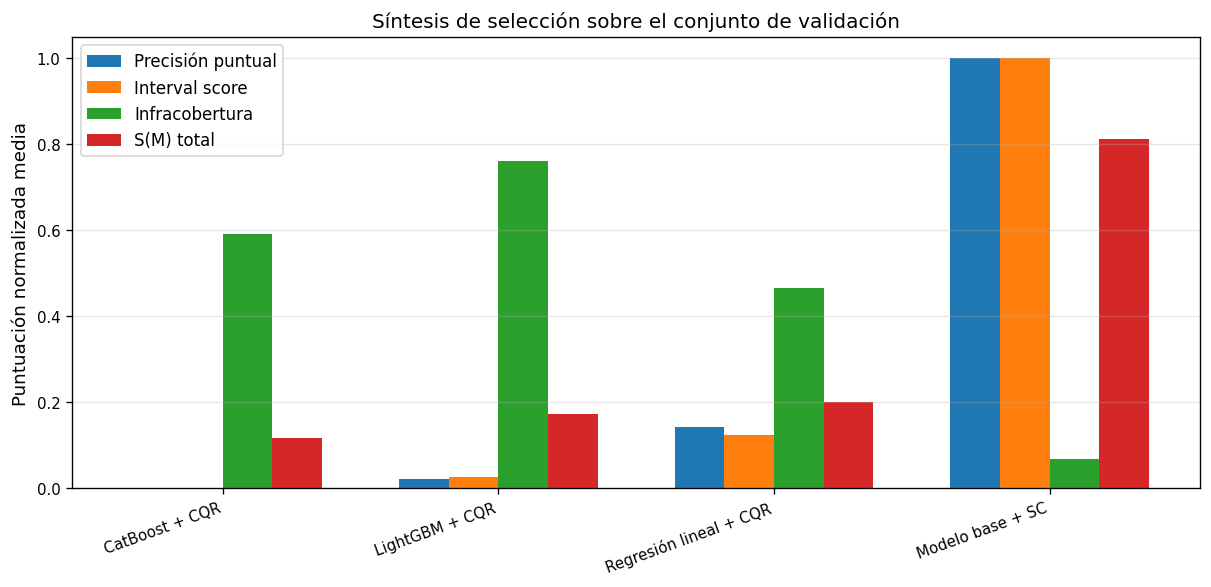

In [9]:
fig, ax = plt.subplots(figsize=(10.2, 5.0))

plot_df = ranking_df.sort_values("selection_score").copy()
x = np.arange(len(plot_df))
width = 0.18

ax.bar(x - 1.5 * width, plot_df["mean_point_score"], width, label="Precisión puntual")
ax.bar(x - 0.5 * width, plot_df["mean_interval_quality_score"], width, label="Interval score")
ax.bar(x + 0.5 * width, plot_df["mean_coverage_score"], width, label="Infracobertura")
ax.bar(x + 1.5 * width, plot_df["selection_score"], width, label="S(M) total")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=20, ha="right")
ax.set_ylabel("Puntuación normalizada media")
ax.set_title("Síntesis de selección sobre el conjunto de validación")
ax.grid(axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
selection_score_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "model_selection_score_summary.png",
)
plt.show()


## Construcción de los conjuntos de datos para la extensión del horizonte a 1–24 horas

Una vez determinado el método ganador, lo extendemos a todos los horizontes horarios.

In [10]:
# Definimos varias funciones de ingeniería de características para la extensión de horizontes.

TARGET_COLUMN = "o3"
PROCESSED_DATA_PATH = DATA_PROCESSED_DIR / "o3_hourly.parquet"

SPLIT_DATE_RANGES = {
    TRAIN_SPLIT: (pd.Timestamp("2020-01-01 00:00:00"), pd.Timestamp("2022-12-31 23:00:00")),
    CALIBRATION_SPLIT: (pd.Timestamp("2023-01-01 00:00:00"), pd.Timestamp("2023-12-31 23:00:00")),
    VALIDATION_SPLIT: (pd.Timestamp("2024-01-01 00:00:00"), pd.Timestamp("2024-12-31 23:00:00")),
    TEST_SPLIT: (pd.Timestamp("2025-01-01 00:00:00"), pd.Timestamp("2025-12-31 23:00:00")),
}

ORIGIN_LAG_HOURS = [1, 2, 3, 6, 12]
TARGET_LAG_HOURS = [48]
ROLLING_WINDOWS = [6, 24]

def add_cyclical_encoding(values: pd.Series, period: int) -> tuple[pd.Series, pd.Series]:
    """Devuelve la codificación seno/coseno de una serie cíclica."""
    angle = 2 * np.pi * values / period
    return np.sin(angle), np.cos(angle)

def assign_chronological_split(target_timestamp: pd.Timestamp) -> str | None:
    """Efectúa la partición a partir de un instante objetivo."""
    for split_name, (start, end) in SPLIT_DATE_RANGES.items():
        if start <= target_timestamp <= end:
            return split_name
    return None

def remove_exact_duplicate_features(df: pd.DataFrame, candidate_features: list[str]) -> tuple[list[str], dict[str, str]]:
    """Elimina duplicados exactos dentro de un horizonte."""
    selected_features: list[str] = []
    dropped_duplicates: dict[str, str] = {}

    for feature in candidate_features:
        duplicate_of = None
        for selected in selected_features:
            if df[feature].equals(df[selected]):
                duplicate_of = selected
                break

        if duplicate_of is None:
            selected_features.append(feature)
        else:
            dropped_duplicates[feature] = duplicate_of

    return selected_features, dropped_duplicates

def build_origin_features(hourly_df: pd.DataFrame) -> pd.DataFrame:
    """Construye las variables disponibles en el origen de predicción."""
    base = hourly_df[["timestamp", TARGET_COLUMN]].copy()
    base = base.sort_values("timestamp").reset_index(drop=True)

    base["o3_at_origin"] = base[TARGET_COLUMN]

    for lag in ORIGIN_LAG_HOURS:
        base[f"o3_lag_{lag}h"] = base[TARGET_COLUMN].shift(lag)

    for window in ROLLING_WINDOWS:
        rolling = base[TARGET_COLUMN].rolling(window=window, min_periods=1)
        base[f"o3_roll_mean_{window}h"] = rolling.mean()
        base[f"o3_roll_std_{window}h"] = rolling.std()

    base["o3_roll_max_24h"] = base[TARGET_COLUMN].rolling(window=24, min_periods=1).max()
    valid_count_24h = base[TARGET_COLUMN].notna().astype(int).rolling(window=24, min_periods=1).sum()
    base["o3_roll_missing_ratio_24h"] = 1 - valid_count_24h / 24

    return base

CALENDAR_FEATURE_COLUMNS = [
    "target_hour_sin",
    "target_hour_cos",
    "target_dayofweek_sin",
    "target_dayofweek_cos",
    "target_month_sin",
    "target_month_cos",
    "target_is_weekend",
]
ORIGIN_VALUE_FEATURE_COLUMNS = ["o3_at_origin"]
ORIGIN_LAG_FEATURE_COLUMNS = [f"o3_lag_{lag}h" for lag in ORIGIN_LAG_HOURS]
TARGET_LAG_FEATURE_COLUMNS = ["o3_prev_day_same_hour", "o3_target_lag_48h"]
ROLLING_FEATURE_COLUMNS = [
    "o3_roll_mean_6h",
    "o3_roll_mean_24h",
    "o3_roll_std_6h",
    "o3_roll_std_24h",
    "o3_roll_max_24h",
]
QUALITY_FEATURE_COLUMNS = ["o3_roll_missing_ratio_24h"]

CANDIDATE_FEATURE_COLUMNS = (
    CALENDAR_FEATURE_COLUMNS
    + ORIGIN_VALUE_FEATURE_COLUMNS
    + ORIGIN_LAG_FEATURE_COLUMNS
    + TARGET_LAG_FEATURE_COLUMNS
    + ROLLING_FEATURE_COLUMNS
    + QUALITY_FEATURE_COLUMNS
)


def build_modeling_dataset_for_horizon(origin_features_df: pd.DataFrame, horizon: int) -> tuple[pd.DataFrame, list[str], dict[str, str]]:
    """Construye el conjunto de datos para un horizonte concreto."""
    df = origin_features_df.copy()
    o3 = df[TARGET_COLUMN]

    df["horizon"] = horizon
    df["origin_timestamp"] = df["timestamp"]
    df["target_timestamp"] = df["timestamp"] + pd.to_timedelta(horizon, unit="h")
    df["y"] = o3.shift(-horizon)

    df["o3_prev_day_same_hour"] = o3.shift(24 - horizon)
    df["o3_target_lag_48h"] = o3.shift(48 - horizon)

    target_ts = df["target_timestamp"]
    df["target_hour"] = target_ts.dt.hour
    df["target_dayofweek"] = target_ts.dt.dayofweek
    df["target_month"] = target_ts.dt.month

    df["target_hour_sin"], df["target_hour_cos"] = add_cyclical_encoding(df["target_hour"], 24)
    df["target_dayofweek_sin"], df["target_dayofweek_cos"] = add_cyclical_encoding(df["target_dayofweek"], 7)

    df["target_month_sin"], df["target_month_cos"] = add_cyclical_encoding(df["target_month"] - 1, 12)
    df["target_is_weekend"] = df["target_dayofweek"].isin([5, 6]).astype(int)

    df["split"] = df["target_timestamp"].apply(assign_chronological_split)
    df = df.loc[df["split"].notna()].reset_index(drop=True)

    feature_columns, dropped_duplicates = remove_exact_duplicate_features(df, CANDIDATE_FEATURE_COLUMNS)

    keep_columns = [
        "horizon",
        "split",
        "origin_timestamp",
        "target_timestamp",
        "y",
        *feature_columns,
    ]
    modeling_df = df[keep_columns].copy()

    return modeling_df, feature_columns, dropped_duplicates

In [11]:
# Carga del conjunto de datos procesado y construcción de los 24 conjuntos de datos.

if RUN_HORIZON_EXTENSION and not REUSE_EXISTING_EXTENSION_TABLES:
    if not PROCESSED_DATA_PATH.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {PROCESSED_DATA_PATH}. Debe ejecutarse antes el notebook 00."
        )

    hourly_df = pd.read_parquet(PROCESSED_DATA_PATH).copy()
    hourly_df["timestamp"] = pd.to_datetime(hourly_df["timestamp"])
    hourly_df = hourly_df.sort_values("timestamp").reset_index(drop=True)

    origin_features_df = build_origin_features(hourly_df)

    extension_datasets: dict[int, pd.DataFrame] = {}
    extension_feature_columns_by_horizon: dict[int, list[str]] = {}
    dropped_duplicate_features_by_horizon: dict[int, dict[str, str]] = {}

    for horizon in EXTENSION_HORIZONS:
        df_h, feature_cols_h, dropped_h = build_modeling_dataset_for_horizon(origin_features_df, horizon)
        extension_datasets[horizon] = df_h
        extension_feature_columns_by_horizon[horizon] = feature_cols_h
        dropped_duplicate_features_by_horizon[horizon] = dropped_h

        output_path = DATA_EXTENSION_DIR / f"modeling_h{horizon:02d}.parquet"
        df_h.to_parquet(output_path, index=False)

        print(
            f"h={horizon:02d} -> {len(df_h):,} filas | "
            f"{len(feature_cols_h)} variables | duplicados eliminados: {dropped_h}"
        )

    feature_payload_path = DATA_EXTENSION_DIR / "feature_columns_01_24.json"
    feature_payload = {
        "target_column": "y",
        "candidate_feature_columns": CANDIDATE_FEATURE_COLUMNS,
        "feature_columns_by_horizon": {str(k): v for k, v in extension_feature_columns_by_horizon.items()},
        "dropped_duplicate_features_by_horizon": {str(k): v for k, v in dropped_duplicate_features_by_horizon.items()},
    }
    feature_payload_path.write_text(json.dumps(feature_payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Guardado: {feature_payload_path}")

h=01 -> 52,607 filas | 21 variables | duplicados eliminados: {}
h=02 -> 52,606 filas | 21 variables | duplicados eliminados: {}
h=03 -> 52,605 filas | 21 variables | duplicados eliminados: {}
h=04 -> 52,604 filas | 21 variables | duplicados eliminados: {}
h=05 -> 52,603 filas | 21 variables | duplicados eliminados: {}
h=06 -> 52,602 filas | 21 variables | duplicados eliminados: {}
h=07 -> 52,601 filas | 21 variables | duplicados eliminados: {}
h=08 -> 52,600 filas | 21 variables | duplicados eliminados: {}
h=09 -> 52,599 filas | 21 variables | duplicados eliminados: {}
h=10 -> 52,598 filas | 21 variables | duplicados eliminados: {}
h=11 -> 52,597 filas | 21 variables | duplicados eliminados: {}
h=12 -> 52,596 filas | 20 variables | duplicados eliminados: {'o3_prev_day_same_hour': 'o3_lag_12h'}
h=13 -> 52,595 filas | 21 variables | duplicados eliminados: {}
h=14 -> 52,594 filas | 21 variables | duplicados eliminados: {}
h=15 -> 52,593 filas | 21 variables | duplicados eliminados: {}
h=1

## Extensión del ganador a horizontes de 1 a 24 horas

La siguiente celda entrena un modelo de CatBoost MultiQuantile para cada horizonte. Para evitar una nueva búsqueda completa de hiperparámetros en los 24 horizontes, se reutilizan las configuraciones seleccionadas en la validación cruzada temporal de los horizontes de 1, 4, 12 y 24 horas, asignando a cada nuevo horizonte la configuración del más próximo.

In [12]:
# Entrenamiento y evaluación de CatBoost + CQR para h = 1-24.

ANCHOR_HORIZONS = [1, 4, 12, 24]
CATBOOST_BEST_PARAMS_PATH = REPORTS_TABLES_DIR / "catboost_best_params.csv"

DEFAULT_CATBOOST_PARAMS = {
    "base": {
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3.0,
        "random_strength": 1.0,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.5,
    },
    "regularized": {
        "learning_rate": 0.04,
        "depth": 6,
        "l2_leaf_reg": 10.0,
        "random_strength": 2.0,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 1.0,
    },
}
DEFAULT_ANCHOR_CONFIG = {
    1: ("base", 345),
    4: ("base", 276),
    12: ("regularized", 475),
    24: ("base", 105),
}

def nearest_anchor_horizon(horizon: int) -> int:
    """Devuelve el horizonte que actúa como ancla más cercano."""
    return min(ANCHOR_HORIZONS, key=lambda a: (abs(horizon - a), a))

def read_catboost_anchor_params(anchor_horizon: int) -> tuple[dict[str, Any], int, str]:
    """Lee los hiperparámetros CatBoost seleccionados para un horizonte ancla."""
    if CATBOOST_BEST_PARAMS_PATH.exists():
        best_df = pd.read_csv(CATBOOST_BEST_PARAMS_PATH)
        row = best_df.loc[best_df["horizon"] == anchor_horizon]
        if not row.empty:
            row = row.iloc[0]
            params = json.loads(row["params_json"])
            config_id = str(row.get("selected_config_id", params.get("config_id", "unknown")))
            params.pop("config_id", None)
            iterations = int(row.get("selected_n_iterations", row.get("selected_iterations", 300)))
            return params, iterations, config_id

    config_id, iterations = DEFAULT_ANCHOR_CONFIG[anchor_horizon]
    return DEFAULT_CATBOOST_PARAMS[config_id].copy(), iterations, config_id


def build_catboost_multiquantile_model(params: dict[str, Any], iterations: int) -> CatBoostRegressor:
    """Construye un modelo CatBoost MultiQuantile para q0.10, q0.90 y q0.50."""
    params = dict(params)
    params.pop("selected_iterations", None)
    params.pop("selected_config_id", None)

    alpha_values = f"{LOWER_QUANTILE},{UPPER_QUANTILE},{MEDIAN_QUANTILE}"

    return CatBoostRegressor(
        **params,
        iterations=int(iterations),
        loss_function=f"MultiQuantile:alpha={alpha_values}",
        random_seed=RANDOM_STATE,
        thread_count=-1,
        nan_mode="Min",
        allow_writing_files=False,
        verbose=False,
    )

def prepare_split(df: pd.DataFrame, feature_columns: Sequence[str], split_name: str) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Extrae X, y y metadatos de una partición."""
    split_df = df.loc[df["split"] == split_name].copy()
    split_df = split_df.loc[split_df["y"].notna()].sort_values("target_timestamp").reset_index(drop=True)

    X = split_df.loc[:, list(feature_columns)].copy()
    y = split_df["y"].astype(float).copy()
    metadata = split_df[["horizon", "split", "origin_timestamp", "target_timestamp"]].copy()

    return X, y, metadata

def extract_catboost_multiquantile_predictions(model: CatBoostRegressor, X: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extrae q0.10, q0.90 y q0.50 de CatBoost MultiQuantile."""
    raw = np.asarray(model.predict(Pool(X)), dtype=float)

    if raw.ndim == 1:
        raise ValueError("La predicción MultiQuantile debería tener varias columnas, pero es unidimensional.")

    # CatBoost suele devolver (n_observaciones, n_cuantiles). Se deja un control por si cambia la forma.
    if raw.shape[1] >= 3:
        lower = raw[:, 0]
        upper = raw[:, 1]
        median = raw[:, 2]
    elif raw.shape[0] >= 3 and raw.shape[1] == len(X):
        lower = raw[0, :]
        upper = raw[1, :]
        median = raw[2, :]
    else:
        raise ValueError(f"Ha ocurrido un error en la predicción de MultiQuantile: {raw.shape}")

    ordered_lower = np.minimum(lower, upper)
    ordered_upper = np.maximum(lower, upper)

    return ordered_lower, ordered_upper, median

def build_interval_frame(
    metadata: pd.DataFrame,
    y_true: pd.Series,
    q_lower: np.ndarray,
    q_upper: np.ndarray,
    q_median: np.ndarray,
    q_hat: float,
    model_id: str,
    split_name: str,
    anchor_horizon: int,
    selected_config_id: str,
    selected_iterations: int,
) -> pd.DataFrame:
    """Se construye una tabla de predicciones e intervalos CQR."""
    out = metadata.copy().reset_index(drop=True)
    out["model"] = model_id
    out["model_display"] = MODEL_REGISTRY[model_id]["display_name"]
    out["label"] = MODEL_REGISTRY[model_id]["label"]
    out["split"] = split_name
    out["y_true"] = y_true.to_numpy(dtype=float)
    out["y_pred_central"] = q_median
    out["lower_prelim"] = q_lower
    out["upper_prelim"] = q_upper
    out["q_hat"] = q_hat
    out["lower"] = q_lower - q_hat
    out["upper"] = q_upper + q_hat
    out["interval_width"] = out["upper"] - out["lower"]
    out["covered"] = (out["y_true"] >= out["lower"]) & (out["y_true"] <= out["upper"])
    out["interval_score"] = interval_score(out["y_true"], out["lower"], out["upper"], ALPHA)
    out["anchor_horizon"] = anchor_horizon
    out["selected_config_id"] = selected_config_id
    out["selected_iterations"] = selected_iterations
    return out

In [13]:
if RUN_HORIZON_EXTENSION and not REUSE_EXISTING_EXTENSION_TABLES:
    if winner_model_id != "catboost":
        raise NotImplementedError(
            "La extensión automática 1-24 se ha implementada para CatBoost + CQR, "
            f"pero el ganador fue otro tipo de modelo: {winner_model_id}."
        )

    extension_interval_frames: list[pd.DataFrame] = []
    extension_training_rows: list[dict[str, Any]] = []

    for horizon in EXTENSION_HORIZONS:
        print("=" * 90)
        print(f"Extensión CatBoost + CQR | h={horizon:02d}")

        df_h = extension_datasets[horizon]
        feature_columns = extension_feature_columns_by_horizon[horizon]

        X_train, y_train, train_meta = prepare_split(df_h, feature_columns, TRAIN_SPLIT)
        X_cal, y_cal, cal_meta = prepare_split(df_h, feature_columns, CALIBRATION_SPLIT)
        X_val, y_val, val_meta = prepare_split(df_h, feature_columns, VALIDATION_SPLIT)
        X_test, y_test, test_meta = prepare_split(df_h, feature_columns, TEST_SPLIT)

        anchor = nearest_anchor_horizon(horizon)
        params, iterations, config_id = read_catboost_anchor_params(anchor)
        model = build_catboost_multiquantile_model(params=params, iterations=iterations)
        model.fit(Pool(X_train, label=y_train), verbose=False)

        cal_lower, cal_upper, cal_median = extract_catboost_multiquantile_predictions(model, X_cal)
        calibration_scores = np.maximum(cal_lower - y_cal.to_numpy(), y_cal.to_numpy() - cal_upper)
        q_hat, q_level = finite_sample_quantile(calibration_scores, ALPHA)

        val_lower, val_upper, val_median = extract_catboost_multiquantile_predictions(model, X_val)
        test_lower, test_upper, test_median = extract_catboost_multiquantile_predictions(model, X_test)

        val_intervals = build_interval_frame(
            metadata=val_meta,
            y_true=y_val,
            q_lower=val_lower,
            q_upper=val_upper,
            q_median=val_median,
            q_hat=q_hat,
            model_id="catboost",
            split_name=VALIDATION_SPLIT,
            anchor_horizon=anchor,
            selected_config_id=config_id,
            selected_iterations=iterations,
        )
        test_intervals = build_interval_frame(
            metadata=test_meta,
            y_true=y_test,
            q_lower=test_lower,
            q_upper=test_upper,
            q_median=test_median,
            q_hat=q_hat,
            model_id="catboost",
            split_name=TEST_SPLIT,
            anchor_horizon=anchor,
            selected_config_id=config_id,
            selected_iterations=iterations,
        )

        extension_interval_frames.extend([val_intervals, test_intervals])

        if SAVE_EXTENSION_MODELS:
            model_path = MODELS_EXTENSION_DIR / f"catboost_multiquantile_h{horizon:02d}.joblib"
            joblib.dump(model, model_path)
        else:
            model_path = Path("no_guardado")

        val_metrics = compute_metrics_from_intervals(val_intervals)
        test_metrics = compute_metrics_from_intervals(test_intervals)

        extension_training_rows.append(
            {
                "horizon": horizon,
                "anchor_horizon": anchor,
                "selected_config_id": config_id,
                "selected_iterations": iterations,
                "n_features": len(feature_columns),
                "n_train": len(y_train),
                "n_calibration": len(y_cal),
                "n_validation": len(y_val),
                "n_test": len(y_test),
                "q_hat": q_hat,
                "q_level": q_level,
                "validation_mae": val_metrics["mae"],
                "validation_rmse": val_metrics["rmse"],
                "validation_coverage": val_metrics["empirical_coverage"],
                "validation_width": val_metrics["mean_width"],
                "validation_interval_score": val_metrics["mean_interval_score"],
                "test_mae": test_metrics["mae"],
                "test_rmse": test_metrics["rmse"],
                "test_coverage": test_metrics["empirical_coverage"],
                "test_width": test_metrics["mean_width"],
                "test_interval_score": test_metrics["mean_interval_score"],
                "model_path": relative_path(model_path),
            }
        )

        print(
            f"h={horizon:02d} | q_hat={q_hat:.3f} | "
            f"validación: MAE={val_metrics['mae']:.3f}, cobertura={val_metrics['empirical_coverage']:.3f}, "
            f"IS={val_metrics['mean_interval_score']:.3f} | "
            f"test: MAE={test_metrics['mae']:.3f}, cobertura={test_metrics['empirical_coverage']:.3f}, "
            f"IS={test_metrics['mean_interval_score']:.3f}"
        )

    winner_extension_intervals_df = pd.concat(extension_interval_frames, ignore_index=True)
    winner_extension_training_df = pd.DataFrame(extension_training_rows)

    intervals_path = REPORTS_INTERVALS_DIR / "catboost_cqr_horizon_01_24_intervals.parquet"
    winner_extension_intervals_df.to_parquet(intervals_path, index=False)
    print(f"Se han guardado los intervalos 1-24: {intervals_path}")

else:
    intervals_path = REPORTS_INTERVALS_DIR / "catboost_cqr_horizon_01_24_intervals.parquet"
    if not intervals_path.exists():
        raise FileNotFoundError(
            "REUSE_EXISTING_EXTENSION_TABLES=True, pero no se encontró "
            f"{intervals_path}."
        )
    winner_extension_intervals_df = pd.read_parquet(intervals_path).copy()
    winner_extension_training_df = pd.DataFrame()

Extensión CatBoost + CQR | h=01
h=01 | q_hat=0.595 | validación: MAE=6.171, cobertura=0.803, IS=29.626 | test: MAE=6.916, cobertura=0.771, IS=33.947
Extensión CatBoost + CQR | h=02
h=02 | q_hat=1.140 | validación: MAE=8.864, cobertura=0.801, IS=40.550 | test: MAE=9.984, cobertura=0.759, IS=46.906
Extensión CatBoost + CQR | h=03
h=03 | q_hat=1.216 | validación: MAE=10.385, cobertura=0.798, IS=46.138 | test: MAE=11.677, cobertura=0.755, IS=53.249
Extensión CatBoost + CQR | h=04
h=04 | q_hat=1.397 | validación: MAE=11.339, cobertura=0.790, IS=49.701 | test: MAE=12.922, cobertura=0.733, IS=58.457
Extensión CatBoost + CQR | h=05
h=05 | q_hat=1.538 | validación: MAE=11.961, cobertura=0.789, IS=52.110 | test: MAE=13.709, cobertura=0.725, IS=61.749
Extensión CatBoost + CQR | h=06
h=06 | q_hat=1.405 | validación: MAE=12.341, cobertura=0.785, IS=53.947 | test: MAE=14.285, cobertura=0.716, IS=64.927
Extensión CatBoost + CQR | h=07
h=07 | q_hat=1.644 | validación: MAE=12.655, cobertura=0.789, IS=5

## Métricas de la extensión multihorizonte

A continuación, se calcularán las métricas del método CatBoost + CQR para cada horizonte entre 1 y 24 horas, que servirán para estudiar el emplazamiento idóneo de la frontera temporal de utilidad.

In [14]:
extension_metric_rows = []
for (split_name, horizon), group in winner_extension_intervals_df.groupby(["split", "horizon"], sort=True):
    metrics = compute_metrics_from_intervals(group)
    metrics.update(
        {
            "model": "catboost",
            "label": "CatBoost + CQR",
            "split": split_name,
            "horizon": int(horizon),
            "nominal_coverage": NOMINAL_COVERAGE,
            "q_hat": float(group["q_hat"].iloc[0]) if "q_hat" in group.columns else np.nan,
            "anchor_horizon": int(group["anchor_horizon"].iloc[0]) if "anchor_horizon" in group.columns else np.nan,
        }
    )
    extension_metric_rows.append(metrics)

winner_extension_metrics_df = pd.DataFrame(extension_metric_rows).sort_values(["split", "horizon"]).reset_index(drop=True)

validation_extension_metrics_df = winner_extension_metrics_df.loc[winner_extension_metrics_df["split"] == VALIDATION_SPLIT].copy()
test_extension_metrics_df = winner_extension_metrics_df.loc[winner_extension_metrics_df["split"] == TEST_SPLIT].copy()

validation_extension_path = save_dataframe_csv(
    validation_extension_metrics_df,
    REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_validation_metrics.csv",
    index=False,
)

test_extension_path = save_dataframe_csv(
    test_extension_metrics_df,
    REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_test_metrics.csv",
    index=False,
)

if not winner_extension_training_df.empty:
    training_extension_path = save_dataframe_csv(
        winner_extension_training_df,
        REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_training_summary.csv",
        index=False,
    )

print("Métricas de validación 1-24:")
display(validation_extension_metrics_df)

print("Métricas de prueba 1-24 (solo evaluación final posterior a la selección):")
display(test_extension_metrics_df)

Tabla guardada: c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_validation_metrics.csv
Tabla guardada: c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_test_metrics.csv
Tabla guardada: c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_training_summary.csv
Métricas de validación 1-24:


,n_samples,mae,rmse,empirical_coverage,coverage_error,undercoverage_loss,overcoverage_margin,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,model,label,split,horizon,nominal_coverage,q_hat,anchor_horizon
24,8437,6.1711,8.6029,0.8025,0.0025,0.0000,0.0025,19.7355,19.3734,29.6262,20.8559,8.6405,11.1058,catboost,CatBoost + CQR,validation,1,0.8000,0.5952,1
25,8437,8.8639,11.8943,0.8006,0.0006,0.0000,0.0006,28.3771,27.9584,40.5502,30.1190,8.2731,11.6629,catboost,CatBoost + CQR,validation,2,0.8000,1.1402,1
26,8437,10.3849,13.6021,0.7984,-0.0016,0.0016,0.0000,33.2749,32.5460,46.1385,34.9418,8.2612,11.9000,catboost,CatBoost + CQR,validation,3,0.8000,1.2155,4
27,8437,11.3389,14.6500,0.7903,-0.0097,0.0097,0.0000,35.8442,35.1185,49.7012,37.5022,8.3205,12.6467,catboost,CatBoost + CQR,validation,4,0.8000,1.3966,4
28,8437,11.9606,15.3667,0.7891,-0.0109,0.0109,0.0000,37.8153,36.8751,52.1102,39.1668,7.9649,13.1208,catboost,CatBoost + CQR,validation,5,0.8000,1.5383,4
29,8437,12.3411,15.8363,0.7851,-0.0149,0.0149,0.0000,38.8702,37.7539,53.9471,40.3172,8.0597,13.4289,catboost,CatBoost + CQR,validation,6,0.8000,1.4053,4
30,8437,12.6549,16.1774,0.7887,-0.0113,0.0113,0.0000,40.0458,39.0146,55.1471,41.5953,7.7871,13.3460,catboost,CatBoost + CQR,validation,7,0.8000,1.6445,4
31,8437,12.8751,16.4088,0.7901,-0.0099,0.0099,0.0000,40.7310,39.7219,55.8578,42.4217,7.6568,13.3341,catboost,CatBoost + CQR,validation,8,0.8000,1.7750,4
32,8437,13.0565,16.6206,0.7915,-0.0085,0.0085,0.0000,40.7707,39.6697,56.4933,42.5735,7.6330,13.2156,catboost,CatBoost + CQR,validation,9,0.8000,2.0936,12
33,8437,13.1599,16.7022,0.7891,-0.0109,0.0109,0.0000,41.2348,40.1154,56.9540,43.2585,7.3723,13.7134,catboost,CatBoost + CQR,validation,10,0.8000,2.2513,12


Métricas de prueba 1-24 (solo evaluación final posterior a la selección):


,n_samples,mae,rmse,empirical_coverage,coverage_error,undercoverage_loss,overcoverage_margin,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,model,label,split,horizon,nominal_coverage,q_hat,anchor_horizon
0,8381,6.9163,9.7275,0.7708,-0.0292,0.0292,0.0000,20.2810,19.5520,33.9467,21.6999,9.0920,13.8289,catboost,CatBoost + CQR,test,1,0.8000,0.5952,1
1,8381,9.9838,13.3969,0.7590,-0.0410,0.0410,0.0000,29.0042,28.3137,46.9056,31.6389,8.6028,15.4993,catboost,CatBoost + CQR,test,2,0.8000,1.1402,1
2,8381,11.6772,15.3566,0.7549,-0.0451,0.0451,0.0000,34.3082,33.4484,53.2488,37.1072,8.3284,16.1795,catboost,CatBoost + CQR,test,3,0.8000,1.2155,4
3,8381,12.9218,16.6476,0.7330,-0.0670,0.0670,0.0000,36.4896,35.7832,58.4566,39.8177,8.1255,18.5777,catboost,CatBoost + CQR,test,4,0.8000,1.3966,4
4,8381,13.7086,17.5090,0.7249,-0.0751,0.0751,0.0000,38.4094,37.5023,61.7486,41.6487,7.7676,19.7470,catboost,CatBoost + CQR,test,5,0.8000,1.5383,4
5,8381,14.2854,18.1275,0.7161,-0.0839,0.0839,0.0000,39.3781,38.3686,64.9267,43.0361,7.7795,20.6061,catboost,CatBoost + CQR,test,6,0.8000,1.4053,4
6,8381,14.7126,18.6282,0.7197,-0.0803,0.0803,0.0000,40.9543,40.1074,66.4512,44.6692,7.2545,20.7732,catboost,CatBoost + CQR,test,7,0.8000,1.6445,4
7,8381,14.9243,18.8558,0.7186,-0.0814,0.0814,0.0000,41.5994,40.6983,67.1370,45.4037,7.3500,20.7851,catboost,CatBoost + CQR,test,8,0.8000,1.7750,4
8,8381,15.1771,19.1551,0.7064,-0.0936,0.0936,0.0000,40.6810,40.0167,68.6299,45.3722,7.4096,21.9544,catboost,CatBoost + CQR,test,9,0.8000,2.0936,12
9,8381,15.3518,19.3440,0.7056,-0.0944,0.0944,0.0000,41.3748,40.7358,69.1722,46.0083,7.1829,22.2527,catboost,CatBoost + CQR,test,10,0.8000,2.2513,12


## Figuras de la extensión a 1–24 horas

Estas figuras muestran cómo evolucionan, sobr eel conjunto de validación, el error puntual, la cobertura, la anchura y el $\textit{interval score}$ del método seleccionado.

Figura guardada: c:\trabajo_github\reports\figures\winner_catboost_cqr_horizon_01_24_validation_metrics.png


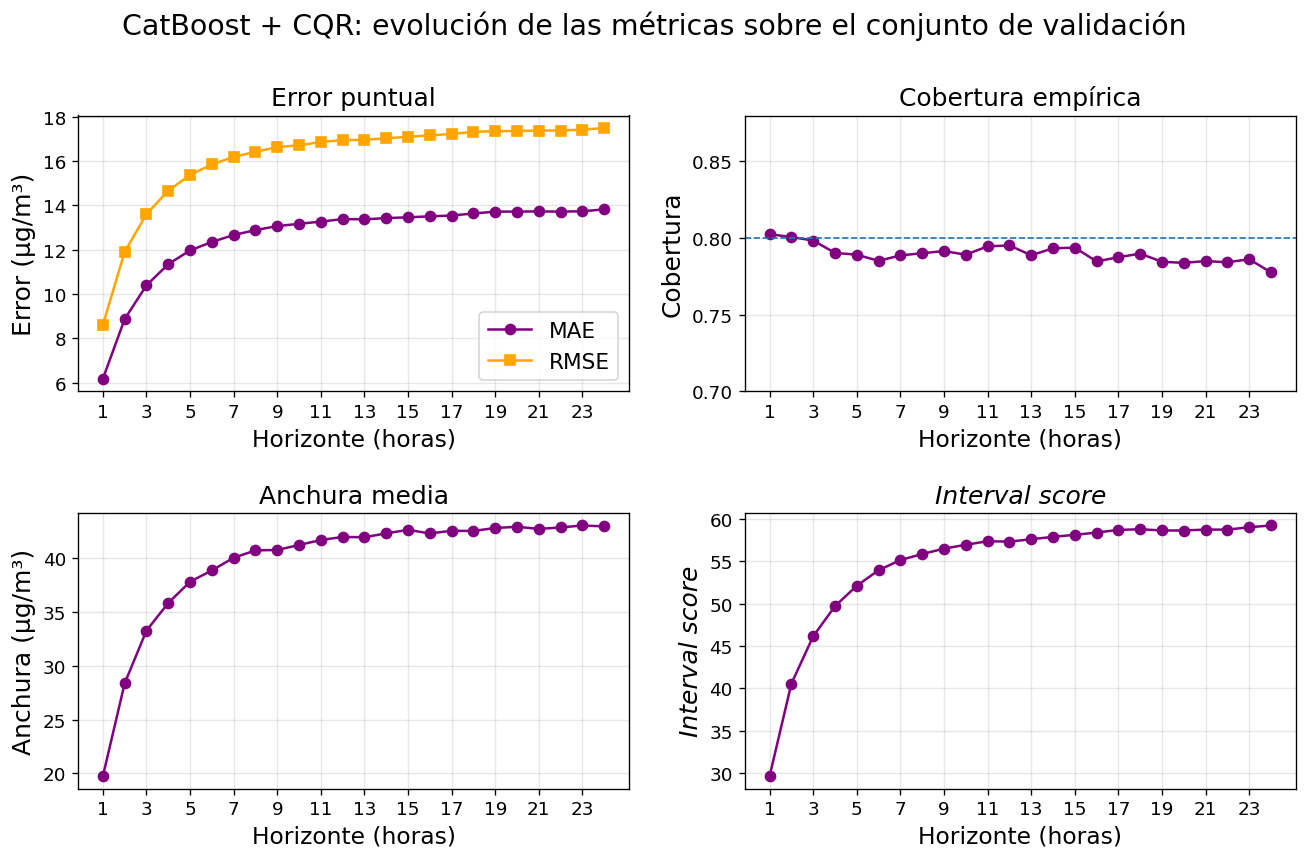

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes = axes.ravel()

x = validation_extension_metrics_df["horizon"]

axes[0].plot(x, validation_extension_metrics_df["mae"], marker="o", label="MAE", color="purple")
axes[0].plot(x, validation_extension_metrics_df["rmse"], marker="s", label="RMSE", color="orange")
axes[0].set_title("Error puntual", fontsize=15)
axes[0].set_ylabel("Error (µg/m³)", fontsize=15)
axes[0].legend(fontsize=13)

axes[1].plot(x, validation_extension_metrics_df["empirical_coverage"], marker="o", color="purple")
axes[1].axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1)
axes[1].set_title("Cobertura empírica", fontsize=15)
axes[1].set_ylabel("Cobertura", fontsize=15)
axes[1].set_ylim(0.70, 0.88)

axes[2].plot(x, validation_extension_metrics_df["mean_width"], marker="o", color="purple")
axes[2].set_title("Anchura media", fontsize=15)
axes[2].set_ylabel("Anchura (µg/m³)", fontsize=15)

axes[3].plot(x, validation_extension_metrics_df["mean_interval_score"], marker="o", color="purple")
axes[3].set_title("Interval score", fontsize=15, fontstyle="italic")
axes[3].set_ylabel("Interval score", fontsize=15, fontstyle="italic")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)", fontsize=14)
    ax.set_xticks(range(1, 25, 2))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=11)

fig.suptitle(
    "CatBoost + CQR: evolución de las métricas sobre el conjunto de validación",
    y=0.95,
    fontsize=17
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94],
    h_pad=2.0,
    w_pad=1.2
)

extension_metrics_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "winner_catboost_cqr_horizon_01_24_validation_metrics.png",
)
plt.show()

Figura guardada: c:\trabajo_github\reports\figures\winner_catboost_cqr_horizon_01_24_validation_vs_test.png


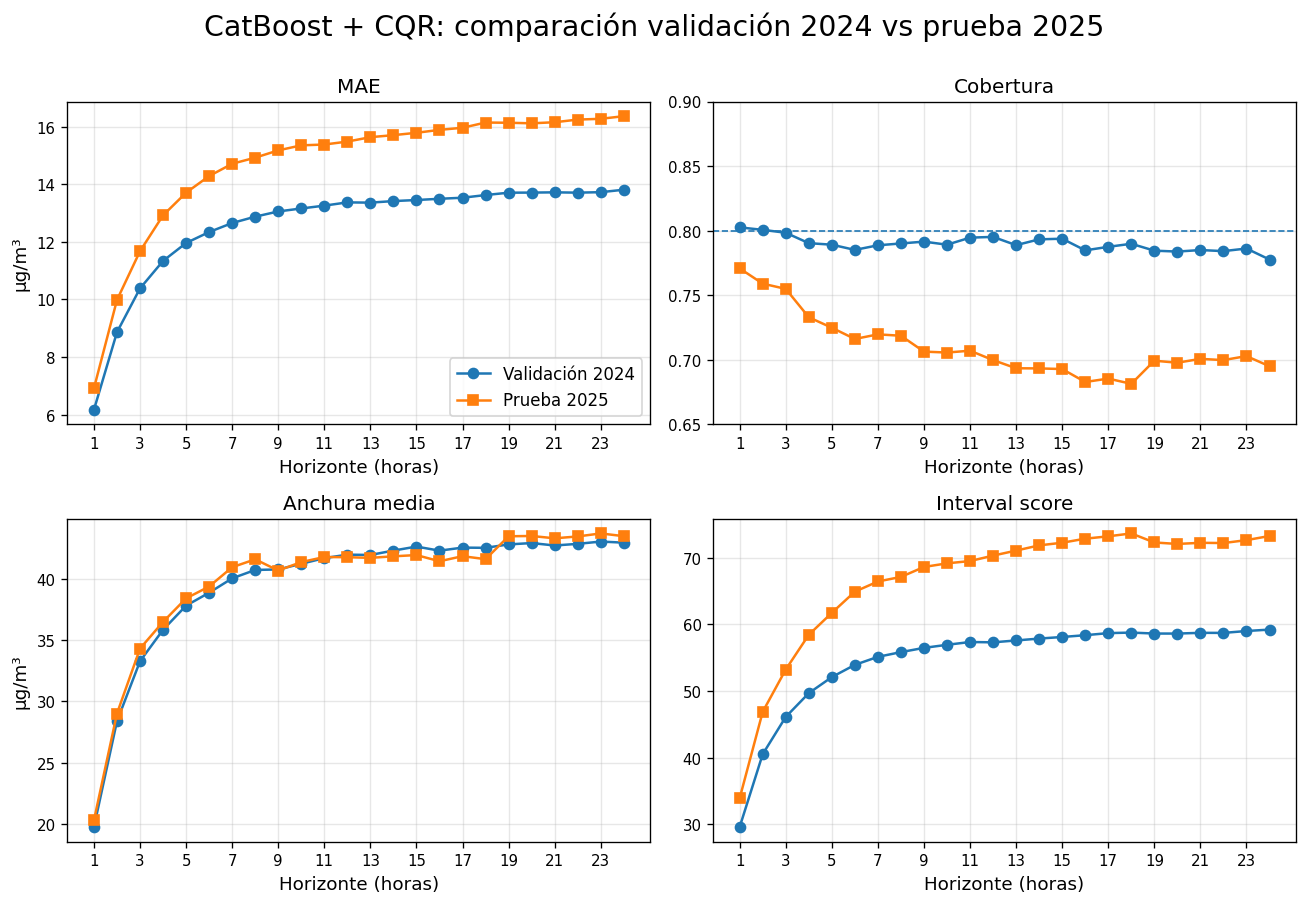

In [16]:
# Figura para comparar los resultados de validación vs. los de prueba
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes = axes.ravel()

metric_specs = [
    ("mae", "MAE", "µg/m³"),
    ("empirical_coverage", "Cobertura", ""),
    ("mean_width", "Anchura media", "µg/m³"),
    ("mean_interval_score", "Interval score", ""),
]

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    ax.plot(validation_extension_metrics_df["horizon"], validation_extension_metrics_df[metric], marker="o", label="Validación 2024")
    ax.plot(test_extension_metrics_df["horizon"], test_extension_metrics_df[metric], marker="s", label="Prueba 2025")
    if metric == "empirical_coverage":
        ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1, label="Cobertura nominal")
        ax.set_ylim(0.65, 0.90)
    ax.set_title(title)
    ax.set_xlabel("Horizonte (horas)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 25, 2))
    ax.grid(True, alpha=0.3)

axes[0].legend()
fig.suptitle("CatBoost + CQR: comparación validación 2024 vs prueba 2025", y=1, fontsize=17)
fig.tight_layout()

extension_validation_test_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "winner_catboost_cqr_horizon_01_24_validation_vs_test.png",
)
plt.show()

In [17]:
compact_horizons = [1, 2, 4, 8, 12, 18, 24]
compact_validation_df = validation_extension_metrics_df.loc[
    validation_extension_metrics_df["horizon"].isin(compact_horizons),
    ["horizon", "mae", "rmse", "empirical_coverage", "undercoverage_loss", "mean_width", "mean_interval_score", "q_hat", "anchor_horizon"],
].copy()

compact_validation_path = save_dataframe_csv(
    compact_validation_df,
    REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_validation_metrics_compact.csv",
    index=False,
)

display(compact_validation_df)

Tabla guardada: c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_validation_metrics_compact.csv


,horizon,mae,rmse,empirical_coverage,undercoverage_loss,mean_width,mean_interval_score,q_hat,anchor_horizon
24,1,6.1711,8.6029,0.8025,0.0000,19.7355,29.6262,0.5952,1
25,2,8.8639,11.8943,0.8006,0.0000,28.3771,40.5502,1.1402,1
27,4,11.3389,14.6500,0.7903,0.0097,35.8442,49.7012,1.3966,4
31,8,12.8751,16.4088,0.7901,0.0099,40.7310,55.8578,1.7750,4
35,12,13.3715,16.9324,0.7952,0.0048,41.9809,57.3251,2.2860,12
41,18,13.6258,17.3088,0.7899,0.0101,42.5378,58.7876,2.4345,12
47,24,13.8107,17.4801,0.7776,0.0224,42.9600,59.2358,0.6393,24


## Comprobaciones finales

Finalmente, verificamos que la selección se haya realizado sobre el conjunto de validación (2024), que el modelo ganador quede guardado y que se hayan generado las tablas y figuras codificadas.

In [18]:
expected_table_paths = [
    selection_metrics_path,
    ranking_path,
    selection_decision_path,
    validation_extension_path,
    test_extension_path,
    compact_validation_path,
]
if "training_extension_path" in globals():
    expected_table_paths.append(training_extension_path)

expected_figure_paths = [
    selection_score_figure_path,
    extension_metrics_figure_path,
    extension_validation_test_figure_path,
]

missing_paths = [path for path in expected_table_paths + expected_figure_paths if not Path(path).exists()]
if missing_paths:
    raise FileNotFoundError(f"No se han generado los siguientes archivos esperados: {missing_paths}")

if winner_model_id != "catboost":
    warnings.warn(f"El modelo ganador no es CatBoost, es {winner_model_id}.")

final_check_df = pd.DataFrame(
    {
        "check": [
            "seleccion_solo_validacion_2024",
            "modelo_ganador_registrado",
            "extension_1_24_generada",
            "tablas_principales_guardadas",
            "figuras_principales_guardadas",
            "test_no_usado_en_seleccion",
        ],
        "status": [
            "ok",
            f"ok ({winner_label})",
            "ok" if set(validation_extension_metrics_df["horizon"]) == set(EXTENSION_HORIZONS) else "revisar",
            "ok",
            "ok",
            "ok",
        ],
    }
)

display(final_check_df)

print("Notebook completado.")
print("Tablas principales:")
for path in expected_table_paths:
    print(f"- {path}")
print("Figuras principales:")
for path in expected_figure_paths:
    print(f"- {path}")

,check,status
0,seleccion_solo_validacion_2024,ok
1,modelo_ganador_registrado,ok (CatBoost + CQR)
2,extension_1_24_generada,ok
3,tablas_principales_guardadas,ok
4,figuras_principales_guardadas,ok
5,test_no_usado_en_seleccion,ok


Notebook completado.
Tablas principales:
- c:\trabajo_github\reports\tables\model_selection_validation_metrics.csv
- c:\trabajo_github\reports\tables\model_selection_ranking.csv
- c:\trabajo_github\reports\tables\model_selection_decision_summary.csv
- c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_validation_metrics.csv
- c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_test_metrics.csv
- c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_validation_metrics_compact.csv
- c:\trabajo_github\reports\tables\winner_catboost_cqr_horizon_01_24_training_summary.csv
Figuras principales:
- c:\trabajo_github\reports\figures\model_selection_score_summary.png
- c:\trabajo_github\reports\figures\winner_catboost_cqr_horizon_01_24_validation_metrics.png
- c:\trabajo_github\reports\figures\winner_catboost_cqr_horizon_01_24_validation_vs_test.png
